In [12]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Load data
X = np.load("/content/drive/MyDrive/X_images.npy", mmap_mode='r')[:10000]
y = np.load('/content/drive/MyDrive/y_labels.npy')[:10000]
num_classes = len(np.unique(y))

In [22]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [23]:
# Convert to PyTorch tensors and rearrange dimensions to (N, C, H, W)
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [24]:
# Flatten image tensors for DNN input using reshape instead of view
X_train_dnn = X_train.reshape(X_train.size(0), -1)
X_test_dnn = X_test.reshape(X_test.size(0), -1)

In [25]:
# DataLoaders
train_loader = DataLoader(TensorDataset(X_train_dnn, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_dnn, y_test), batch_size=64)

In [ ]:
# DNN MODEL
class DNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DNNModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = DNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 15
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

[DNN] Epoch 1/15, Loss: 1.1927
[DNN] Epoch 2/15, Loss: 1.0561
[DNN] Epoch 3/15, Loss: 1.0197
[DNN] Epoch 4/15, Loss: 0.9940
[DNN] Epoch 5/15, Loss: 0.9732
[DNN] Epoch 6/15, Loss: 0.9503
[DNN] Epoch 7/15, Loss: 0.9443
[DNN] Epoch 8/15, Loss: 0.9275
[DNN] Epoch 9/15, Loss: 0.9221
[DNN] Epoch 10/15, Loss: 0.9108
[DNN] Epoch 11/15, Loss: 0.9062
[DNN] Epoch 12/15, Loss: 0.8919
[DNN] Epoch 13/15, Loss: 0.8951
[DNN] Epoch 14/15, Loss: 0.8709
[DNN] Epoch 15/15, Loss: 0.8689


In [ ]:
#Evaluation

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

In [ ]:
# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

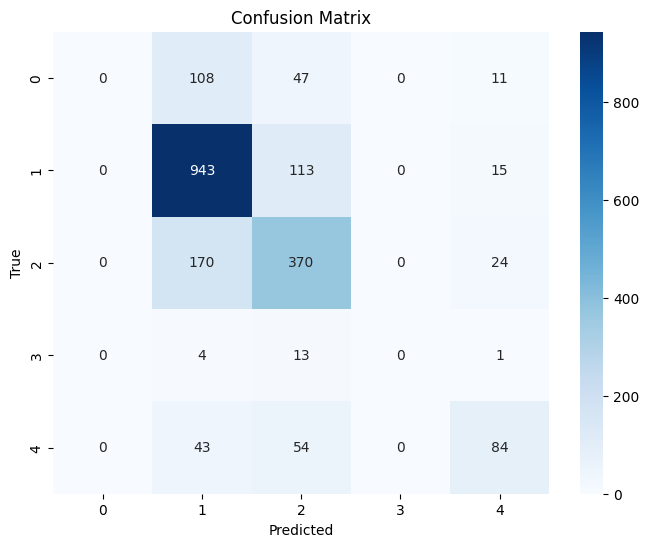

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_true, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       166
           1       0.74      0.88      0.81      1071
           2       0.62      0.66      0.64       564
           3       0.00      0.00      0.00        18
           4       0.62      0.46      0.53       181

    accuracy                           0.70      2000
   macro avg       0.40      0.40      0.40      2000
weighted avg       0.63      0.70      0.66      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# AUC Score (One-vs-Rest)
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.7915


In [ ]:
#tuning 1: changing the epoch to 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = DNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

[DNN] Epoch 1/20, Loss: 1.1816
[DNN] Epoch 2/20, Loss: 1.0601
[DNN] Epoch 3/20, Loss: 1.0226
[DNN] Epoch 4/20, Loss: 0.9899
[DNN] Epoch 5/20, Loss: 0.9727
[DNN] Epoch 6/20, Loss: 0.9572
[DNN] Epoch 7/20, Loss: 0.9414
[DNN] Epoch 8/20, Loss: 0.9324
[DNN] Epoch 9/20, Loss: 0.9214
[DNN] Epoch 10/20, Loss: 0.9120
[DNN] Epoch 11/20, Loss: 0.9069
[DNN] Epoch 12/20, Loss: 0.8952
[DNN] Epoch 13/20, Loss: 0.8821
[DNN] Epoch 14/20, Loss: 0.8831
[DNN] Epoch 15/20, Loss: 0.8737
[DNN] Epoch 16/20, Loss: 0.8683
[DNN] Epoch 17/20, Loss: 0.8721
[DNN] Epoch 18/20, Loss: 0.8686
[DNN] Epoch 19/20, Loss: 0.8490
[DNN] Epoch 20/20, Loss: 0.8396


In [ ]:
#Evaluation 1

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

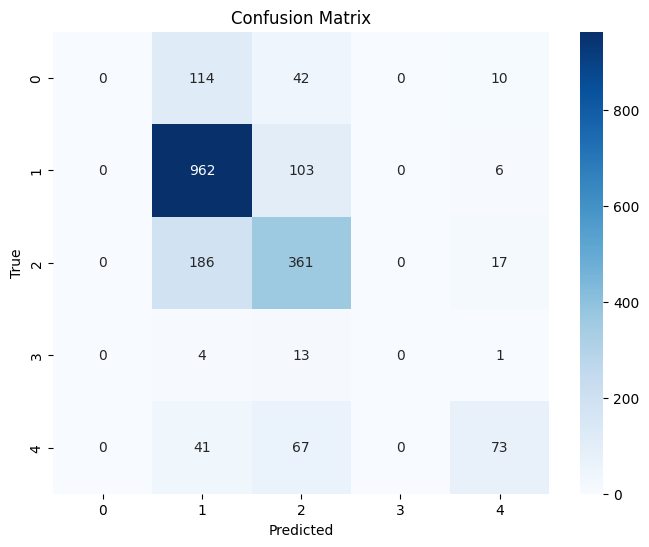

In [ ]:
# Confusion matrix 1
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report 1
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       166
           1       0.74      0.90      0.81      1071
           2       0.62      0.64      0.63       564
           3       0.00      0.00      0.00        18
           4       0.68      0.40      0.51       181

    accuracy                           0.70      2000
   macro avg       0.41      0.39      0.39      2000
weighted avg       0.63      0.70      0.66      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# AUC Score (One-vs-Rest) 1
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.7925


In [ ]:
#tuning 2: changing the epoch to 10 and adjusting the dropout rate

# DNN MODEL
class tunedDNNModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(tunedDNNModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = tunedDNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")

[DNN] Epoch 1/10, Loss: 1.1058
[DNN] Epoch 2/10, Loss: 0.9802
[DNN] Epoch 3/10, Loss: 0.9433
[DNN] Epoch 4/10, Loss: 0.9150
[DNN] Epoch 5/10, Loss: 0.8874
[DNN] Epoch 6/10, Loss: 0.9028
[DNN] Epoch 7/10, Loss: 0.8579
[DNN] Epoch 8/10, Loss: 0.8516
[DNN] Epoch 9/10, Loss: 0.8349
[DNN] Epoch 10/10, Loss: 0.8186


In [ ]:
#Evaluation 2

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

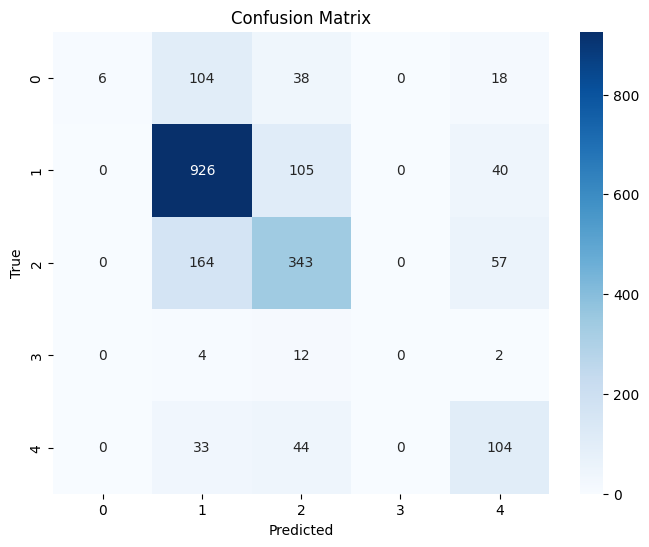

In [ ]:
# Confusion matrix 2
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Classification Report 2
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.04      0.07       166
           1       0.75      0.86      0.80      1071
           2       0.63      0.61      0.62       564
           3       0.00      0.00      0.00        18
           4       0.47      0.57      0.52       181

    accuracy                           0.69      2000
   macro avg       0.57      0.42      0.40      2000
weighted avg       0.71      0.69      0.66      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# AUC Score (One-vs-Rest) 2
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.8030


In [26]:
#tuning 3: adding the extra layer and changing the epoch to 10
class TunedDNNModel(nn.Module):
    def __init__(self, input_dim, num_classes, dropout_rate=0.3):
        super(TunedDNNModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_dnn.shape[1]
model = TunedDNNModel(input_dim=input_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"[DNN] Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss / len(train_loader):.4f}")



[DNN] Epoch 1/10, Loss: 1.2028
[DNN] Epoch 2/10, Loss: 0.9693
[DNN] Epoch 3/10, Loss: 0.9045
[DNN] Epoch 4/10, Loss: 0.8561
[DNN] Epoch 5/10, Loss: 0.8081
[DNN] Epoch 6/10, Loss: 0.7557
[DNN] Epoch 7/10, Loss: 0.7101
[DNN] Epoch 8/10, Loss: 0.6658
[DNN] Epoch 9/10, Loss: 0.6321
[DNN] Epoch 10/10, Loss: 0.5783


In [27]:
#Evaluation 3

from sklearn.metrics import classification_report

model.eval()
all_preds = []
all_probs = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.argmax(probs, dim=1).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

# Stack all batches
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_targets)

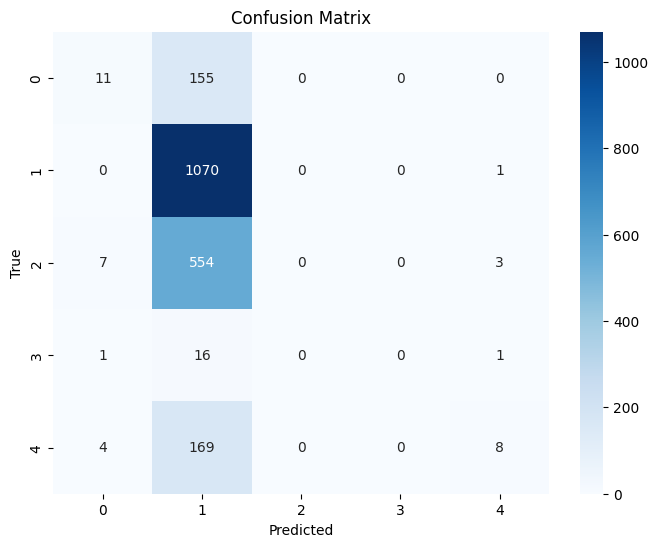

In [28]:
# Confusion matrix 3
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [29]:
# Classification Report 3
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.07      0.12       166
           1       0.54      1.00      0.71      1071
           2       0.00      0.00      0.00       564
           3       0.00      0.00      0.00        18
           4       0.62      0.04      0.08       181

    accuracy                           0.54      2000
   macro avg       0.33      0.22      0.18      2000
weighted avg       0.39      0.54      0.39      2000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# AUC Score (One-vs-Rest) 3
try:
    y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
    auc = roc_auc_score(y_true_bin, y_probs, multi_class='ovr')
    print(f"\nAUC Score (One-vs-Rest): {auc:.4f}")
except Exception as e:
    print(f"\nAUC could not be computed: {e}")


AUC Score (One-vs-Rest): 0.7242
